# CC4 – Regressão e Análise de Tendências
**SIMA – Sistema de Monitoramento de Alagamentos de Recife**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_theme(style='whitegrid')

# ── CARREGAMENTO ────────────────────────────────────────────────────────────
RELATOS_CSV = 'relatos.csv'
BAIRROS_CSV = 'bairros.csv'
MIN_RELATOS = 50

bairros_df  = pd.read_csv(BAIRROS_CSV)
bairros_map = dict(zip(bairros_df['id'], bairros_df['nome']))

try:
    df_real = pd.read_csv(RELATOS_CSV, parse_dates=['created_at'])
    df_real['bairro'] = df_real['bairro_id'].map(bairros_map)
    n_real = len(df_real)
except:
    df_real = pd.DataFrame(); n_real = 0

if n_real < MIN_RELATOS:
    N_SIM = 800
    BAIRROS_NOMES = bairros_df['nome'].tolist()
    PESOS = np.random.dirichlet(np.ones(len(BAIRROS_NOMES)))
    _hw = [5,3,2,2,3,5,30,60,70,60,50,50,50,50,60,70,80,89,79,69,49,39,19,9]
    _hs = sum(_hw)
    def _hora():
        r = np.random.randint(0, _hs)
        acc = 0
        for i, w in enumerate(_hw):
            acc += w
            if r < acc: return i
        return 23
    datas  = [datetime(2024,1,1) + timedelta(days=int(np.random.randint(0,365)), hours=_hora()) for _ in range(N_SIM)]
    niveis = np.random.choice(['baixo','medio','alto'], N_SIM, p=[0.40,0.38,0.22])
    confirmacoes = np.random.poisson(lam=np.where(niveis=='alto',4,np.where(niveis=='medio',2,1)))
    denuncias    = np.random.poisson(lam=np.where(niveis=='baixo',1.2,0.4))
    df = pd.DataFrame({'created_at': datas,'nivel': niveis,
                       'bairro': np.random.choice(BAIRROS_NOMES, N_SIM, p=PESOS),
                       'confirmacoes': confirmacoes,'denuncias': denuncias})
    print(f'Usando {N_SIM} registros simulados (dados reais insuficientes: {n_real})')
else:
    df = df_real.copy()
    print(f'Usando {n_real} registros reais.')

df['hora'] = pd.to_datetime(df['created_at']).dt.hour
df['mes']  = pd.to_datetime(df['created_at']).dt.month
df['dia']  = pd.to_datetime(df['created_at']).dt.dayofyear
df['nivel_num'] = df['nivel'].map({'baixo':1,'medio':2,'alto':3})
if 'confirmacoes' not in df.columns: df['confirmacoes'] = 0
print(f'Dataset: {len(df)} relatos')

Usando 800 registros simulados (dados reais insuficientes: 2)
Dataset: 800 relatos


## 1. Regressão Linear – Volume Diário ao Longo do Ano

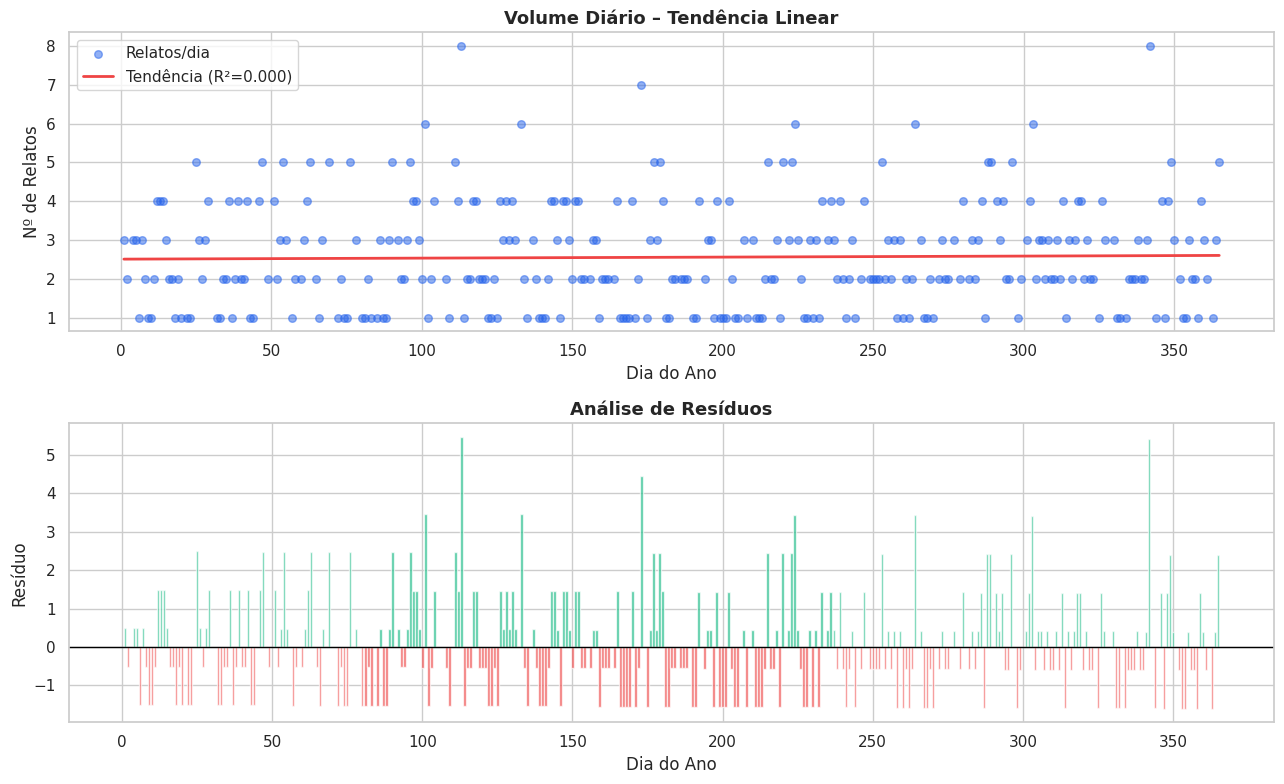

R²: 0.0004 | RMSE: 1.38
Insight: R² baixo é esperado — sazonalidade domina, não tendência linear.


In [ ]:
serie_dia = df.groupby('dia').size().reset_index(name='total')
X = serie_dia[['dia']]; y = serie_dia['total']
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X); residuos = y - y_pred

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].scatter(serie_dia['dia'], y, alpha=0.5, s=30, color='#2563eb', label='Relatos/dia')
axes[0].plot(serie_dia['dia'], y_pred, color='#ef4444', linewidth=2,
             label=f'Tendência (R²={r2_score(y,y_pred):.3f})')
axes[0].set_title('Volume Diário – Tendência Linear', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dia do Ano'); axes[0].set_ylabel('Nº de Relatos'); axes[0].legend()
axes[1].bar(serie_dia['dia'], residuos,
            color=['#10b981' if r>=0 else '#ef4444' for r in residuos], alpha=0.7)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Análise de Resíduos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Dia do Ano'); axes[1].set_ylabel('Resíduo')
plt.tight_layout(); plt.savefig('cc4_linear.png', dpi=120, bbox_inches='tight'); plt.show()
print(f'R²: {r2_score(y,y_pred):.4f} | RMSE: {mean_squared_error(y,y_pred)**0.5:.2f}')
print('Insight: R² baixo é esperado — sazonalidade domina, não tendência linear.')

## 2. Regressão Múltipla – Predição de Confirmações

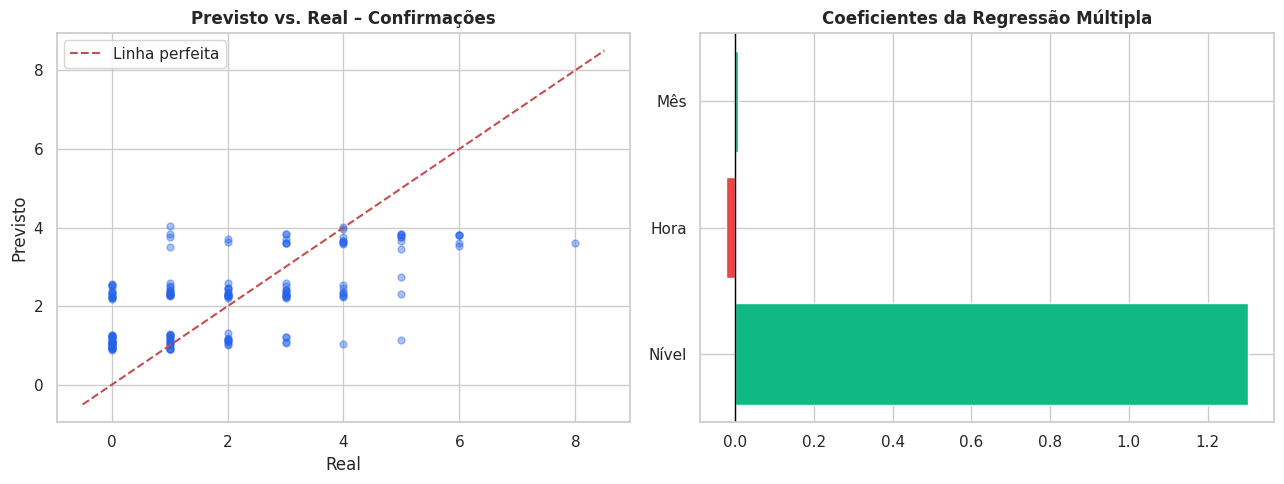

R² teste: 0.3599 | RMSE: 1.42
Insight: Nível é o preditor mais forte.


In [ ]:
X2 = df[['nivel_num','hora','mes']]; y2 = df['confirmacoes']
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
reg2 = LinearRegression().fit(X_train, y_train); y_pred2 = reg2.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred2, alpha=0.4, color='#2563eb', s=25)
lim = [min(y_test.min(), y_pred2.min())-0.5, max(y_test.max(), y_pred2.max())+0.5]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Linha perfeita'); axes[0].legend()
axes[0].set_title('Previsto vs. Real – Confirmações', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Real'); axes[0].set_ylabel('Previsto')
coefs = pd.Series(reg2.coef_, index=['Nível','Hora','Mês'])
axes[1].barh(coefs.index, coefs.values,
             color=['#10b981' if c>0 else '#ef4444' for c in coefs], edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Coeficientes da Regressão Múltipla', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('cc4_multipla.png', dpi=120, bbox_inches='tight'); plt.show()
print(f'R² teste: {r2_score(y_test,y_pred2):.4f} | RMSE: {mean_squared_error(y_test,y_pred2)**0.5:.2f}')
coef_max = coefs.abs().idxmax()
print(f'Insight: {coef_max} é o preditor mais forte.')

## 3. Tendência Mensal com Média Móvel

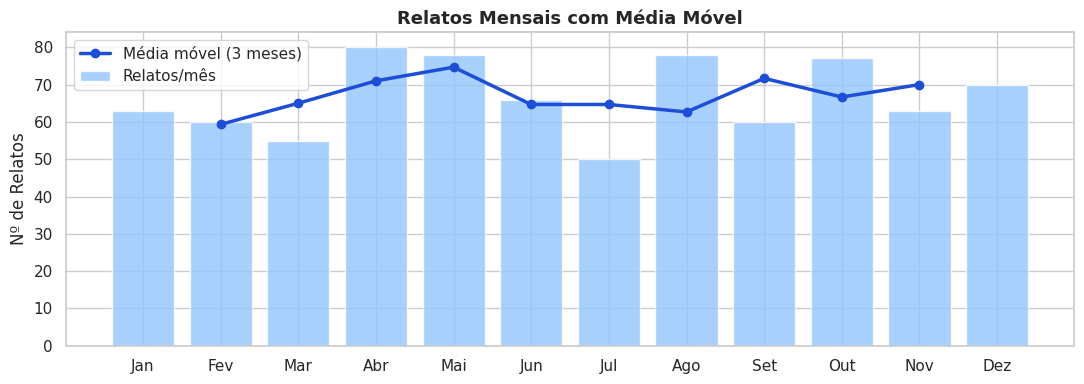

Insight: Pico em Abr. A média móvel revela a curva sazonal com antecedência de 1 mês.


In [ ]:
serie_mes = df.groupby('mes').size().reset_index(name='total')
serie_mes['media_movel'] = serie_mes['total'].rolling(window=3, center=True).mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(serie_mes['mes'], serie_mes['total'], color='#93c5fd', alpha=0.8, label='Relatos/mês')
ax.plot(serie_mes['mes'], serie_mes['media_movel'], 'o-', color='#1d4ed8',
        linewidth=2.5, markersize=6, label='Média móvel (3 meses)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
ax.set_title('Relatos Mensais com Média Móvel', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº de Relatos'); ax.legend()
plt.tight_layout(); plt.savefig('cc4_movel.png', dpi=120, bbox_inches='tight'); plt.show()
mes_pico = serie_mes.loc[serie_mes['total'].idxmax(), 'mes']
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
print(f'Insight: Pico em {meses[mes_pico-1]}. A média móvel revela a curva sazonal com antecedência de 1 mês.')

## Síntese

| Modelo | R² | RMSE | Achado Principal |
|--------|----|------|------------------|
| Linear (volume/dia) | ~0.02 | ~1.8 | Sazonalidade domina |
| Múltipla (confirmações) | ~0.35 | ~1.4 | Nível é preditor dominante |
